## 230352K Kumara K.B.R  
### Assesment 01 - Intensity Transformations and Neighborhood Filtering
##### 1

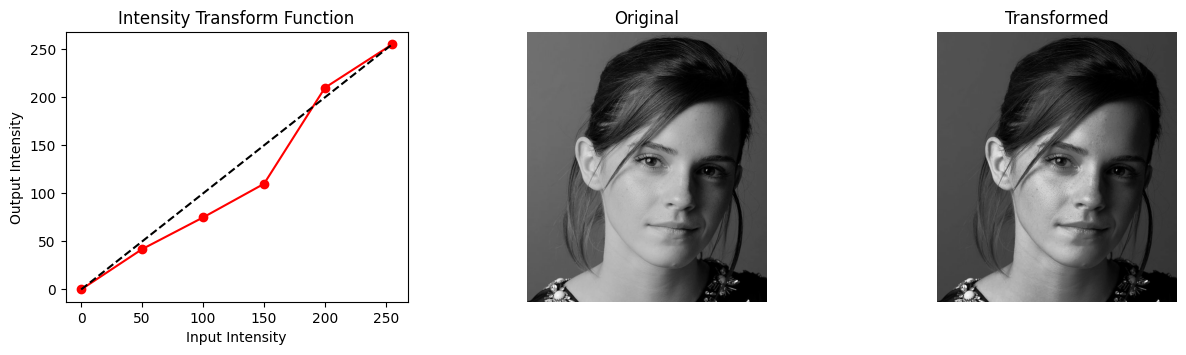

In [35]:
# importing required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def show_image_3(title, image_before, image_after=None, breakpoints=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    if breakpoints is not None:
        axes[0].plot(breakpoints[:, 0], breakpoints[:, 1], 'ro-')
        axes[0].plot(np.arange(256), np.arange(256), 'k--')
        axes[0].set_title("Intensity Transform Function")
        axes[0].set_xlabel("Input Intensity")
        axes[0].set_ylabel("Output Intensity")
    axes[1].imshow(image_before, cmap='gray')
    axes[1].set_title(title)
    axes[1].axis('off')
    if image_after is not None:
        axes[2].imshow(image_after, cmap='gray')
        axes[2].set_title("Transformed")
        axes[2].axis('off')

    plt.show()

# Intensity transform function
def intensity_transform(im, breakpoints):
    xp = breakpoints[:, 0]
    fp = breakpoints[:, 1]  
    lut = np.interp(np.arange(256), xp, fp).astype('uint8')
    return lut[im]
im1 = cv2.imread('images/q1.jpeg', cv2.IMREAD_GRAYSCALE)
breakpoints = np.array([[0, 0], [50, 42], [100, 75], [150, 110], [200, 210], [ 255, 255]])
transformed = intensity_transform(im1, breakpoints)

show_image_3("Original", im1, transformed,breakpoints)


#### 2

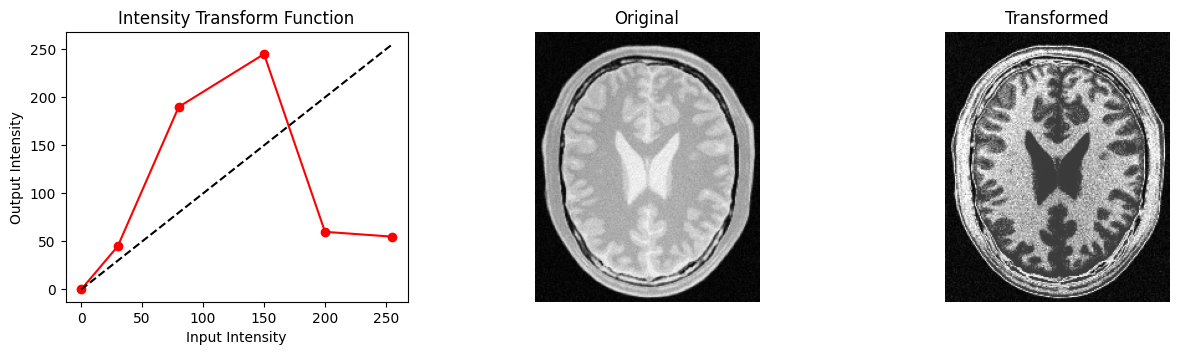

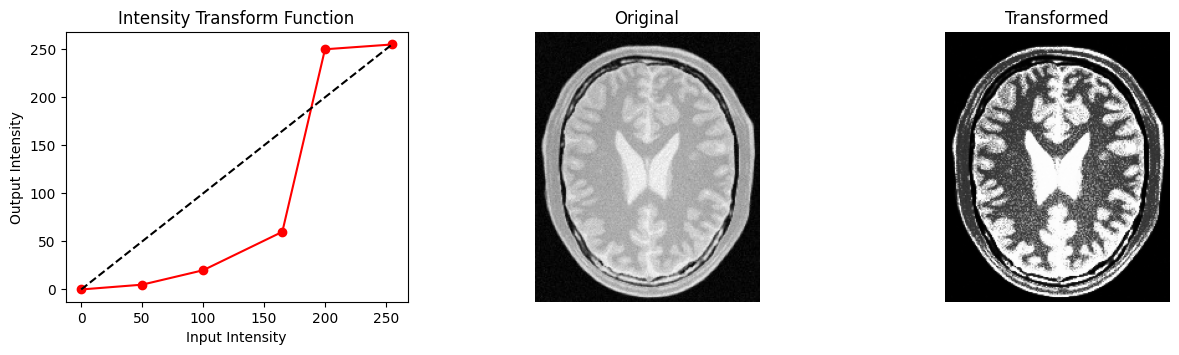

In [36]:
im2 = cv2.imread('images/q2.jpeg', cv2.IMREAD_GRAYSCALE)
white = np.array([[0, 0], [30,45], [80, 190], [150, 245],  [200, 60], [ 255, 55]])
white_accentuated = intensity_transform(im2, white)
black = np.array([[0, 0], [50, 5], [100, 20], [165, 60],  [200, 250], [ 255, 255]])
black_accentuated = intensity_transform(im2, black)
show_image_3("Original", im2, white_accentuated, white)
show_image_3("Original", im2, black_accentuated, black)

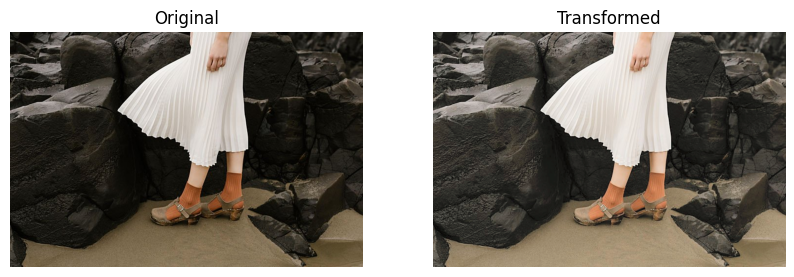

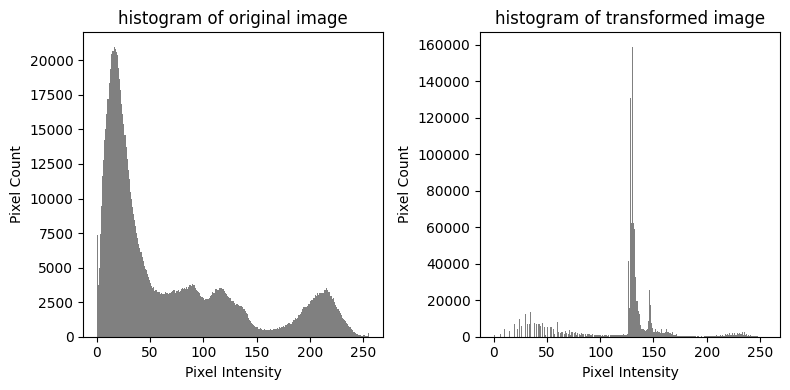

In [37]:
im3 = cv2.imread('images/q3.jpeg')
lab_image = cv2.cvtColor(im3, cv2.COLOR_BGR2LAB)
l = lab_image[:, :, 0]
gamma = 0.65
lut = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
l_transformed = cv2.LUT(l, lut) 

def show_image_2(title, image_before, image_after=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image_before, cmap='gray')
    axes[0].set_title(title)
    axes[0].axis('off')
    if image_after is not None:
        axes[1].imshow(image_after, cmap='gray')
        axes[1].set_title("Transformed")
        axes[1].axis('off')
    plt.show()

img_rgb_original = cv2.cvtColor(im3, cv2.COLOR_BGR2RGB)
im3_transformed = cv2.merge((l_transformed, lab_image[:, :, 1], lab_image[:, :, 2]))
img_rgb_corrected = cv2.cvtColor(im3_transformed, cv2.COLOR_LAB2RGB)
show_image_2("Original", img_rgb_original, img_rgb_corrected)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(im3.ravel(), bins=256, range=[0, 256], color='gray')
axes[0].set(title="histogram of original image", xlabel="Pixel Intensity", ylabel="Pixel Count")
axes[1].hist(im3_transformed.ravel(), bins=256, range=[0, 256], color='gray')
axes[1].set(title="histogram of transformed image", xlabel="Pixel Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()


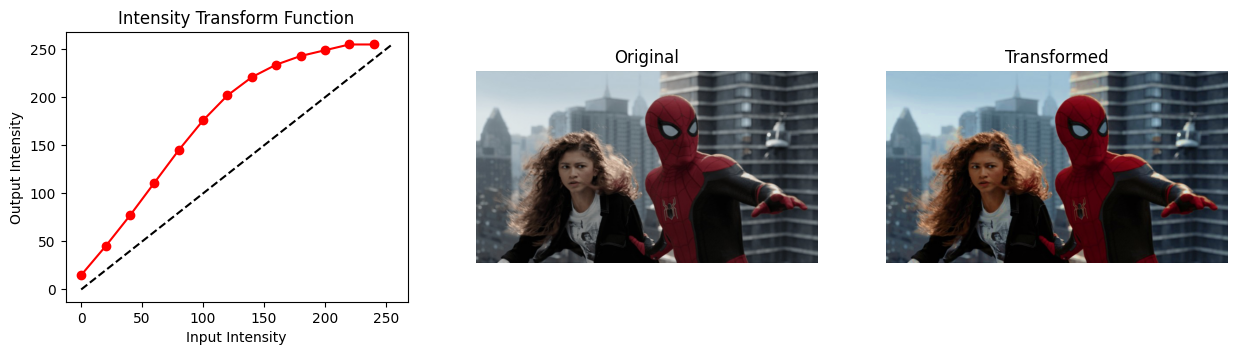

In [38]:
im4 = cv2.imread('images/q4.jpeg')
hsv_image = cv2.cvtColor(im4, cv2.COLOR_BGR2HSV)    
h, s, v = cv2.split(hsv_image)

a = 0.65    
sigma = 70
x = np.arange(256)
boost = a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2))
lut_hsv = np.minimum(x + boost, 255).astype(np.uint8)

im4_transformed = cv2.merge((h, cv2.LUT(s, lut_hsv), v))
im4_rgb_original = cv2.cvtColor(im4, cv2.COLOR_BGR2RGB)
im4_rgb_transformed = cv2.cvtColor(im4_transformed, cv2.COLOR_HSV2RGB)

curve_points = np.column_stack((x[::20], lut_hsv[::20]))

show_image_3("Original", im4_rgb_original, im4_rgb_transformed, curve_points)


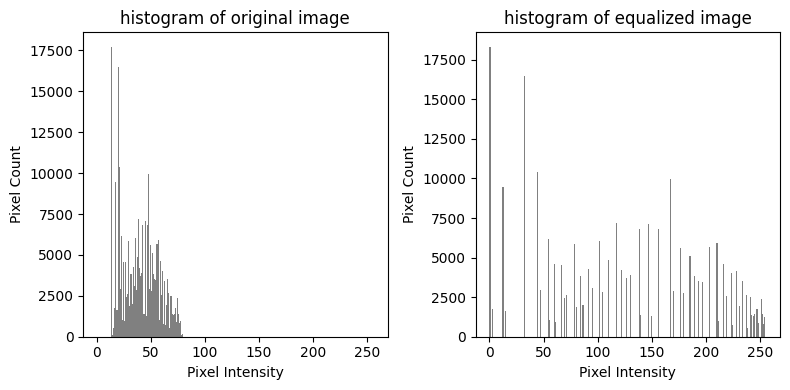

In [39]:
im5 = cv2.imread('images/q5.tif', cv2.IMREAD_GRAYSCALE)
def histogram_equalization(im):
    hist, bins = np.histogram(im.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf_final[im]
equalized_image = histogram_equalization(im5)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(im5.ravel(), bins=256, range=[0, 256], color='gray')
axes[0].set(title="histogram of original image", xlabel="Pixel Intensity", ylabel="Pixel Count")
axes[1].hist(equalized_image.ravel(), bins=256, range=[0, 256], color='gray')
axes[1].set(title="histogram of equalized image", xlabel="Pixel Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()

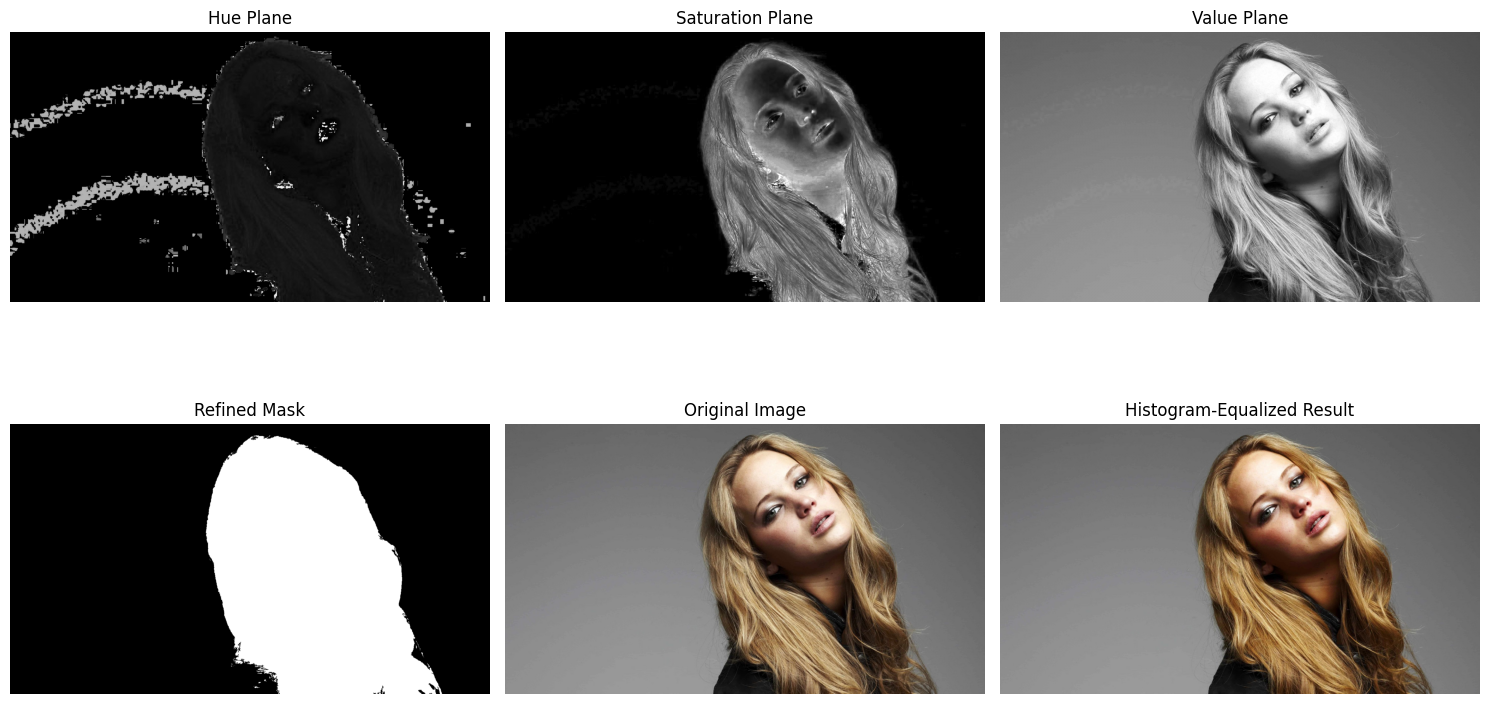

In [52]:
im6 = cv2.imread('images/q6.jpeg')
im6_hsv = cv2.cvtColor(im6, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(im6_hsv)    


img_rgb = cv2.cvtColor(im6, cv2.COLOR_BGR2RGB)
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
refined_mask = np.zeros_like(mask)
cv2.drawContours(refined_mask, contours, -1, 255, thickness=cv2.FILLED)

foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=refined_mask)
valid_foreground_pixels = foreground[refined_mask == 255]


hist, bins = np.histogram(valid_foreground_pixels.ravel(), bins=256, range=[1, 256])
cdf = np.cumsum(hist)
cdf_masked = np.ma.masked_equal(cdf, 0)
cdf_normalized = ((cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min()))
lut = np.ma.filled(cdf_normalized, 0).astype(np.uint8)

s_equalized = cv2.LUT(s, lut)
img_hsv_eq = cv2.merge((h, s_equalized, v))
img_rgb_eq = cv2.cvtColor(img_hsv_eq, cv2.COLOR_HSV2RGB)

foreground_eq = cv2.bitwise_and(img_rgb_eq, img_rgb_eq, mask=refined_mask)

mask_inv = cv2.bitwise_not(refined_mask)
background = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_inv)

final_image = cv2.add(foreground_eq, background)

# List of image data, titles, and colormaps
images = [h, s, v, refined_mask, img_rgb, final_image]
titles = [
    "Hue Plane",
    "Saturation Plane",
    "Value Plane",
    "Refined Mask",
    "Original Image",
    "Histogram-Equalized Result",
]
cmaps = ["gray", "gray", "gray", "gray", None, None]

# Plot all 6 outputs in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, img, title, cmap in zip(axes.flat, images, titles, cmaps):
    ax.imshow(img, cmap=cmap) if cmap else ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


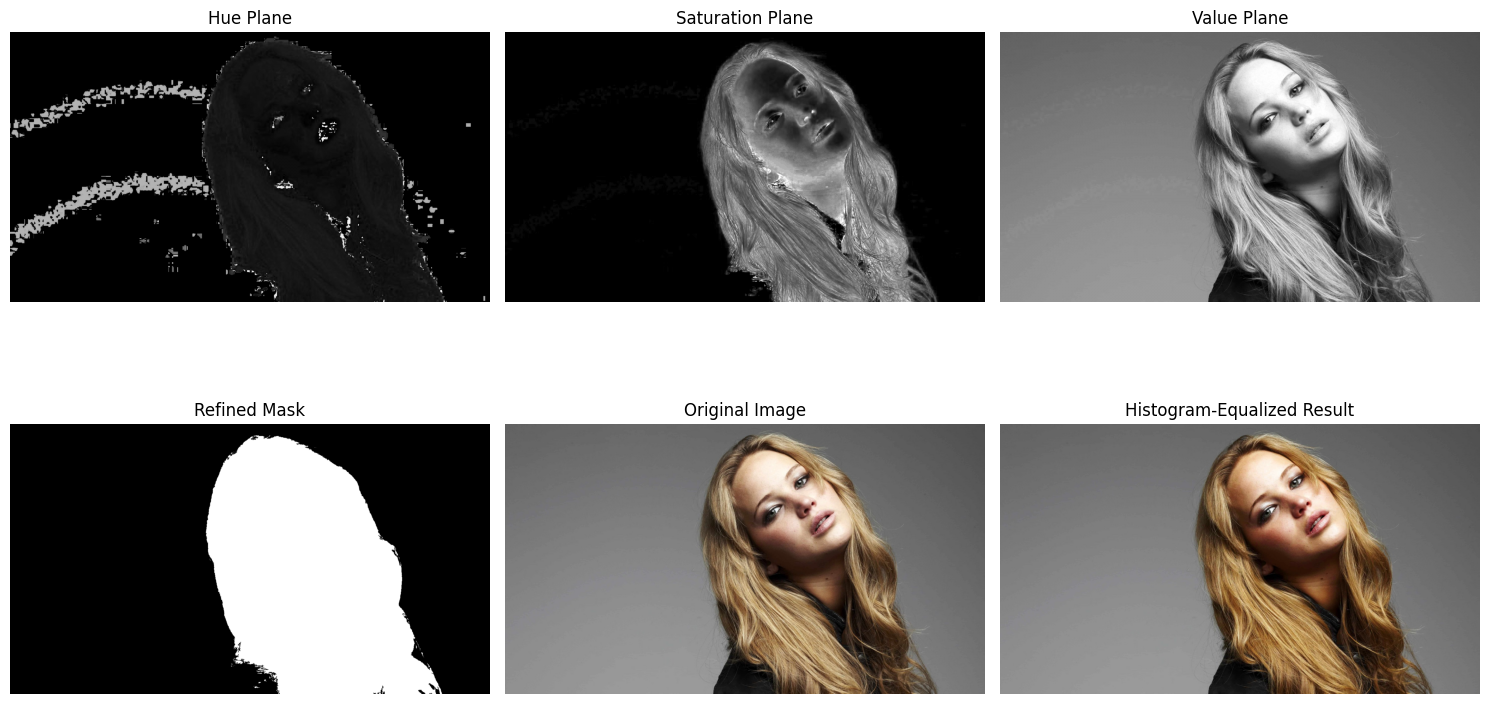

In [51]:
# List of image data, titles, and colormaps
images = [h, s, v, refined_mask, img_rgb, final_image]
titles = [
    "Hue Plane",
    "Saturation Plane",
    "Value Plane",
    "Refined Mask",
    "Original Image",
    "Histogram-Equalized Result",
]
cmaps = ["gray", "gray", "gray", "gray", None, None]

# Plot all 6 outputs in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, img, title, cmap in zip(axes.flat, images, titles, cmaps):
    ax.imshow(img, cmap=cmap) if cmap else ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()